In [1]:
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte2d_settings_ex5_oerfm import get_config
from constraints.continuous2d_oe_1_copy import (
    OddEvenDecompositionPointwiseBoundaryConstraint2D as BC,
    OddEvenDecompositionPointwiseInteriorConstraint2D as EQ,
)
from geometry.meshxd_ds import UniformMeshXYV
from modules.generator import Sample2D
from modules.solution import OddEvenDecompositionConstructor2D
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
bdy_value = rte_config.model.bdy_cond
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXYV(domain=domain, strides=strides)
mesh_r = UniformMeshXYV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_y, dummy_theta = jnp.split(
    jnp.array([0.5, 0.5, -0.1]), 3, axis=0)
params = {}
# eq_instance = rte.apply(params, dummy_x, dummy_y, dummy_theta)
# bc_instance = bc.apply(params, dummy_x, dummy_y, dummy_theta)

In [6]:
# eq_instance.shape, bc_instance.shape

In [7]:
def eq_fn(x, y, theta):
    return partial(rte.apply, params)(x, y, theta)


def bc_fn(x, y, theta):
    return partial(bc.apply, params)(x, y, theta)


def rhs_fn(x, y, theta):
    # 与EQ一致，采用[0, π]平均并除以π
    quadratures = leggauss(num_quads, (0, jnp.pi))
    pts, ws = quadratures

    def q_sym1(x, y, theta):
        return 0.5 * (source_fn(x, y, theta) + source_fn(x, y, -theta))

    def q_asym1(x, y, theta):
        return 0.5 * (source_fn(x, y, theta) - source_fn(x, y, -theta))

    # 角度积分，算平均源项（与EQ一致）
    weighted_sum1 = vmap(q_sym1, [None, None, 0])(x, y, pts) * ws
    avg_q1 = jnp.sum(weighted_sum1) / jnp.pi

    rhs = jnp.stack(
        [
            avg_q1.squeeze(),
            kn**2 * (q_sym1(x, y, theta) - avg_q1).squeeze(),
            kn * q_asym1(x, y, theta).squeeze(),
        ],
        axis=0,
    )
    return rhs


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = Sample2D(
    domain=domain, collocation_sizes=collocation_sizes, mode=mode)
pts_int, pts_left, pts_right, pts_lower, pts_upper = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
    sampler.pts_lower,
    sampler.pts_upper,
)

In [9]:
# Evaluate the functions
bc_left, bc_right, bc_lower, bc_upper = (
    vmap_bc_fn(*pts_left),
    vmap_bc_fn(*pts_right),
    vmap_bc_fn(*pts_lower),
    vmap_bc_fn(*pts_upper),
)
print(
    f"bc_left.shape: {bc_left.shape}, bc_right.shape: {bc_right.shape}, bc_lower.shape: {bc_lower.shape}, bc_upper.shape: {bc_upper.shape}"
)

bc_left.shape: (8192, 128), bc_right.shape: (8192, 128), bc_lower.shape: (8192, 128), bc_upper.shape: (8192, 128)


In [10]:
eq_int = vmap_eq_fn(*pts_int)
print(f"eq_int.shape: {eq_int.shape}")  # ((Nx-2) * (Ny-2) * (Ntheta-2),3,32)

eq_int.shape: (25200, 3, 128)


In [11]:
x_int, y_int, theta_int = pts_int
pts_int = x_int.squeeze(), y_int.squeeze(), theta_int.squeeze()
rhs_int = vmap_rhs_fn(*pts_int)
print(f"rhs_int.shape: {rhs_int.shape}")

rhs_int.shape: (25200, 3)


In [12]:
# Save the data
matrix_A = np.concatenate(
    [bc_left, bc_right, bc_lower, bc_upper, eq_int.reshape(-1, num_unknowns)],
    axis=0,
)

vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size_x, bdy_size_y, bdy_size_theta = collocation_sizes["boundary"]
vector_b[: 2 * bdy_size_y * bdy_size_theta,
         0] = bdy_value["f_l"](pts_left[1]).squeeze()
vector_b[
    2 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta,
    0,
] = bdy_value["f_r"](pts_right[1]).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta,
    0,
] = bdy_value["f_b"](pts_lower[0]).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 2 * bdy_size_x * bdy_size_theta: 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta,
    0,
] = bdy_value["f_t"](pts_upper[0]).squeeze()

vector_b[
    4 * bdy_size_y * bdy_size_theta + 4 * bdy_size_x * bdy_size_theta:,
    0,
] = rhs_int.reshape(-1)

print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (108368, 128), Vector b: (108368, 1)


In [13]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

num_zero = np.sum(matrix_A == 0).item()
total = matrix_A.size
sparsity = num_zero / total
print(f"A的稀疏度 = {sparsity:.2%} (零元素比例)")
num_zero = np.sum(vector_b == 0).item()
total = vector_b.size
sparsity = num_zero / total
print(f"b的稀疏度 = {sparsity:.2%} (零元素比例)")

Matrix A 内存 105.83 MB
Vector b 内存 0.83 MB
A的稀疏度 = 0.00% (零元素比例)
b的稀疏度 = 53.49% (零元素比例)


In [14]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (128, 1)


In [15]:
error = np.abs(matrix_A @ vector_U - vector_b)
error.max(), error.mean()

(0.06122724977293004, 0.008295657445144948)

In [16]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns,
)
constructor = OddEvenDecompositionConstructor2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [17]:
def approx_fn(x, y, theta):
    return partial(constructor.apply, params)(x, y, theta)

In [ ]:
def aver_fn(x, y):
    quadratures = leggauss(num_quads, (-jnp.pi, jnp.pi))
    pts, ws = quadratures
    weighted_sum = vmap(approx_fn, [None, None, 0])(x, y, pts) @ ws
    return weighted_sum / jnp.pi / 2

In [30]:
# vmap_approx_fn = vmap(approx_fn)
approx_fn = jit(approx_fn)

In [31]:
dummy_z = jnp.array([0.1, -1.0, 0.0])
dummy_x, dummy_y, dummy_v = jnp.split(dummy_z, 3, axis=-1)
print(f"f({dummy_z}) = {approx_fn(dummy_x, dummy_y, dummy_v)}")

f([ 0.1 -1.   0. ]) = 1.2234615779066247


In [32]:
data = np.load(f"../src/data/rte2d_ex5_ref_{kn:.1e}.npz")
print("Keys in data:", data.keys())

Keys in data: KeysView(NpzFile '../src/data/rte2d_ex5_ref_1.0e-01.npz' with keys: mesh_x, mesh_y, rho)


In [33]:
mesh_x, mesh_y = data["mesh_x"], data["mesh_y"]
f_ex = data["rho"]

X, Y = np.meshgrid(mesh_x, mesh_y)
f_approx = vmap(aver_fn, [0, 0])(X.reshape(-1, 1),
                                 Y.reshape(-1, 1)).reshape(X.shape)
f_ex.shape, f_ex.max(), f_ex.min()

((65, 65), 0.34368962354547394, 0.008520079952642673)

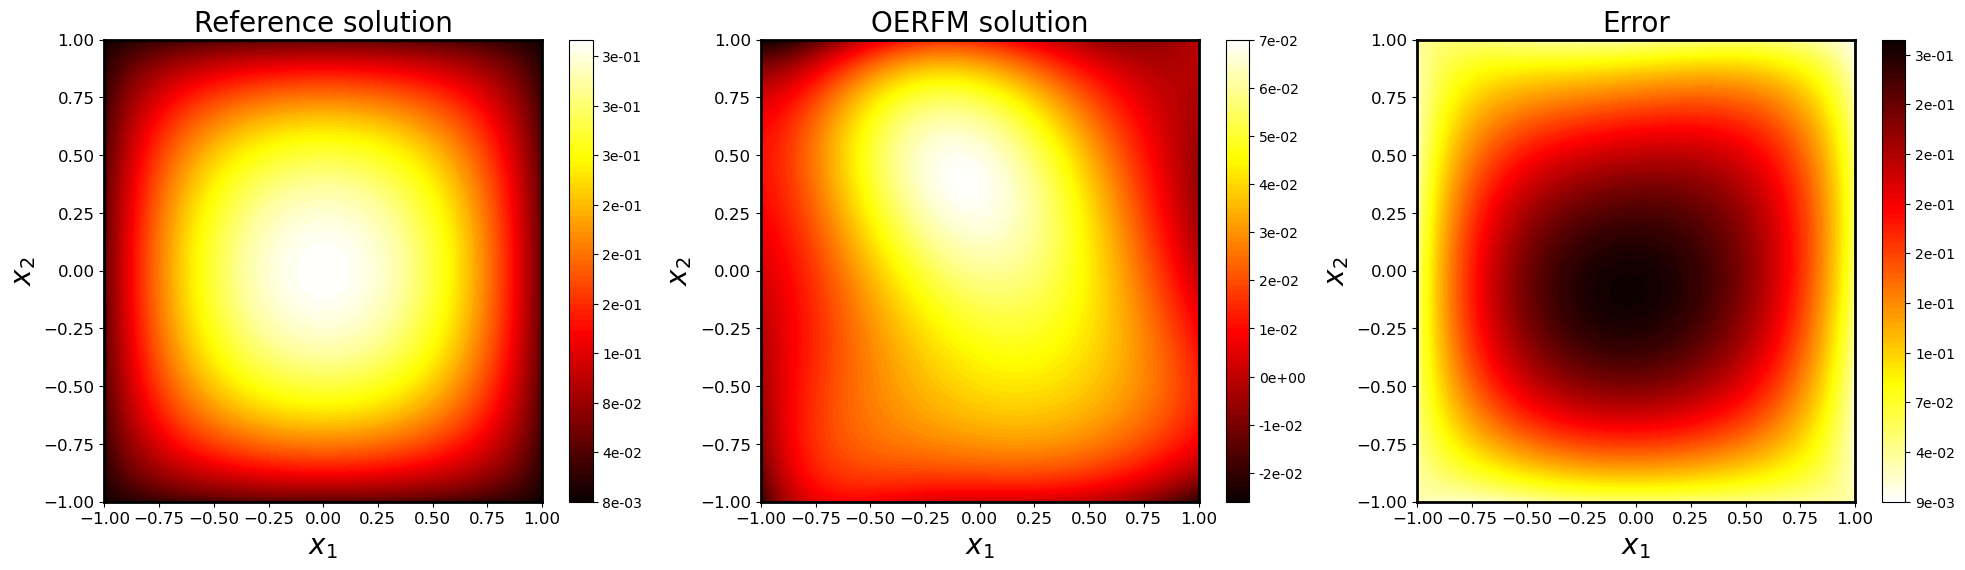

In [34]:
F, F_hat = f_ex, f_approx

font_format = {"size": 20}

plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
plt.contourf(X, Y, F, 100, cmap="hot")
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

ax2 = plt.subplot(1, 3, 2)
plt.contourf(X, Y, F_hat, 100, cmap="hot")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("OERFM solution", font_format)
# # line width of four axises
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)

ax3 = plt.subplot(1, 3, 3)
plt.contourf(X, Y, np.abs(F - F_hat), 100, cmap="hot_r")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("Error", font_format)
# # line width of four axises
ax3.spines["bottom"].set_linewidth(2)
ax3.spines["left"].set_linewidth(2)
ax3.spines["right"].set_linewidth(2)
ax3.spines["top"].set_linewidth(2)
# plt.savefig(f"./figures/aprfm2d_{kn:.1e}_contourf_ex5.png", dpi=300)
plt.show()
plt.close()

In [35]:
jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F)

Array(0.83901359, dtype=float64)

In [25]:
# # 对比同一“速度变量”：参考解和数值解的 -grad rho
# dx = mesh_x[1] - mesh_x[0]
# dy = mesh_y[1] - mesh_y[0]

# # 参考解 rho = F，数值解 rho_hat = F_hat
# dF_dy, dF_dx = np.gradient(F, dy, dx)
# dFh_dy, dFh_dx = np.gradient(F_hat, dy, dx)

# Vx_ref, Vy_ref = -dF_dx, -dF_dy
# Vx_num, Vy_num = -dFh_dx, -dFh_dy

# # 子采样网格
# ny, nx = X.shape
# step_x = max(1, nx // 16)
# step_y = max(1, ny // 16)

# X_s = X[::step_y, ::step_x]
# Y_s = Y[::step_y, ::step_x]
# Vx_ref_s = Vx_ref[::step_y, ::step_x]
# Vy_ref_s = Vy_ref[::step_y, ::step_x]
# Vx_num_s = Vx_num[::step_y, ::step_x]
# Vy_num_s = Vy_num[::step_y, ::step_x]

# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.quiver(X_s, Y_s, Vx_ref_s, Vy_ref_s)
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$x_2$")
# plt.title("Reference -grad rho")
# plt.axis("equal")

# plt.subplot(1, 2, 2)
# plt.quiver(X_s, Y_s, Vx_num_s, Vy_num_s)
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$x_2$")
# plt.title("OE-APRFM -grad rho_hat")
# plt.axis("equal")

# plt.tight_layout()
# plt.show()

In [26]:
# # # 画固定点 (x0, y0) 关于 theta 的分布（极坐标图）
# x0, y0 = 0.0, 0.0  # 可修改为你关心的点
# num_theta = 128
# theta_arr = jnp.linspace(-jnp.pi, jnp.pi, num_theta)[1:-1, None]
# f_theta = vmap(approx_fn)(jnp.full_like(theta_arr, x0),
#                           jnp.full_like(theta_arr, y0), theta_arr)
# # f_ex_theta = jnp.exp(-x0 - y0) * jnp.ones_like(f_theta)
# plt.figure(figsize=(6, 5))
# ax = plt.subplot(111, polar=True)
# ax.plot(theta_arr.squeeze(), f_theta, linewidth=5,
#         label=r'$f(x_0, y_0, \theta)$')
# # ax.plot(theta_arr.squeeze(), f_ex_theta, linewidth=5,
# #         label=r'$f_{ex}(x_0, y_0)$', linestyle='--')
# ax.legend()
# plt.show()
# err = f_theta - f_ex_theta
# err_l2 = jnp.linalg.norm(err)/jnp.linalg.norm(f_ex_theta)
# err_l2

Relative error at point (1, 0.1): 1.57e-01


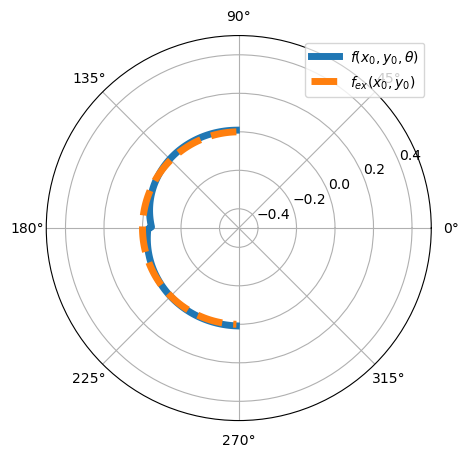

In [27]:
# 画固定点 (x0, y0) 关于 theta 的分布（极坐标图）
x0, y0 = 1, 0.1  # 可修改为你关心的点
num_theta = 128
a = jnp.pi / 2
theta_arr = jnp.linspace(a, a + jnp.pi, num_theta)[1:-1, None]
f_theta = vmap(approx_fn)(
    jnp.full_like(theta_arr, x0), jnp.full_like(theta_arr, y0), theta_arr
)
f_ex_theta = jnp.zeros_like(f_theta)

err = np.linalg.norm(f_theta - f_ex_theta)
print(f"Relative error at point ({x0}, {y0}): {err:.2e}")

plt.figure(figsize=(6, 5))
ax = plt.subplot(111, polar=True)
ax.plot(theta_arr.squeeze(), f_theta, linewidth=5,
        label=r"$f(x_0, y_0, \theta)$")
ax.plot(
    theta_arr.squeeze(),
    f_ex_theta,
    linewidth=5,
    label=r"$f_{ex}(x_0, y_0)$",
    linestyle="--",
)
ax.set_ylim(-0.5, 0.5)
ax.legend()
plt.show()

In [28]:
# if __name__ == "__main__":
#     # 确保numpy数组已定义
#     mesh_x_np = np.asarray(mesh_x)
#     mesh_y_np = np.asarray(mesh_y)
#     F_np = np.asarray(F)
#     F_hat_np = np.asarray(F_hat)

#     # 确保使用numpy数组
#     F = F_np
#     F_hat = F_hat_np

#     print("=" * 70)
#     print("二维数值解精度验证与误差分析")
#     print("=" * 70)
#     print(f"Solution shape: {F_hat.shape} (ny × nx)")
#     print(f"Knudsen Number: {kn}")
#     print(f"Mesh: {len(mesh_y_np)} × {len(mesh_x_np)} = {F_hat.size} points")
#     print("=" * 70)

#     # ========== 1. 全局误差统计 ==========
#     print("\n【1. 全局误差统计】")
#     error = F - F_hat
#     l2_error = np.linalg.norm(error) / np.linalg.norm(F)
#     l2_abs = np.linalg.norm(error)
#     max_error = np.max(np.abs(error))
#     mean_error = np.mean(np.abs(error))

#     print(f"  相对L2误差:  {l2_error:.6e}")
#     print(f"  绝对L2误差:  {l2_abs:.6e}")
#     print(f"  最大点态误差: {max_error:.6e}")
#     print(f"  平均绝对误差: {mean_error:.6e}")

#     # ========== 2. 边界条件验证 ==========
#     print("\n【2. 边界条件验证】")
#     # 左边界 x=0
#     bc_left_error = np.abs(F_hat[:, 0] - F[:, 0])
#     print(f"  左边界 (x=0):")
#     print(f"    L2误差:      {np.linalg.norm(bc_left_error):.6e}")
#     print(f"    最大误差:    {np.max(bc_left_error):.6e}")
#     print(f"    平均误差:    {np.mean(bc_left_error):.6e}")

#     # 右边界 x=1
#     bc_right_error = np.abs(F_hat[:, -1] - F[:, -1])
#     print(f"  右边界 (x=1):")
#     print(f"    L2误差:      {np.linalg.norm(bc_right_error):.6e}")
#     print(f"    最大误差:    {np.max(bc_right_error):.6e}")
#     print(f"    平均误差:    {np.mean(bc_right_error):.6e}")

#     # 下边界 y=0
#     bc_lower_error = np.abs(F_hat[0, :] - F[0, :])
#     print(f"  下边界 (y=0):")
#     print(f"    L2误差:      {np.linalg.norm(bc_lower_error):.6e}")
#     print(f"    最大误差:    {np.max(bc_lower_error):.6e}")
#     print(f"    平均误差:    {np.mean(bc_lower_error):.6e}")

#     # 上边界 y=1
#     bc_upper_error = np.abs(F_hat[-1, :] - F[-1, :])
#     print(f"  上边界 (y=1):")
#     print(f"    L2误差:      {np.linalg.norm(bc_upper_error):.6e}")
#     print(f"    最大误差:    {np.max(bc_upper_error):.6e}")
#     print(f"    平均误差:    {np.mean(bc_upper_error):.6e}")

#     # ========== 3. PDE残差验证（以二维扩散型为例） ==========
#     print("\n【3. 原始PDE残差验证】")
#     print("  方程: ε·(v_x·∂_x f + v_y·∂_y f) = ⟨f⟩ - f - ε·(v_x + v_y)")
#     # 这里只做一个示例，具体残差计算需结合你的模型
#     dx = mesh_x_np[1] - mesh_x_np[0]
#     dy = mesh_y_np[1] - mesh_y_np[0]
#     dfdx = (F_hat[1:-1, 2:] - F_hat[1:-1, :-2]) / (2 * dx)
#     dfdy = (F_hat[2:, 1:-1] - F_hat[:-2, 1:-1]) / (2 * dy)
#     # 速度平均（假设F_hat为rho(x,y)，否则需加速度积分）
#     avg_f = np.mean(F_hat)
#     lhs_pde = kn * (dfdx + dfdy)
#     rhs_pde = avg_f - F_hat[1:-1, 1:-1] - kn
#     res_pde = lhs_pde - rhs_pde
#     pde_l2 = np.linalg.norm(res_pde) / np.sqrt(res_pde.size)
#     pde_max = np.max(np.abs(res_pde))
#     pde_mean = np.mean(np.abs(res_pde))
#     print(f"  L2(残差)/√N:  {pde_l2:.6e}")
#     print(f"  最大残差:     {pde_max:.6e}")
#     print(f"  平均残差:     {pde_mean:.6e}")

#     # ========== 4. Odd-Even分解验证（如有需要） ==========
#     print("\n【4. Odd-Even分解】")
#     # 二维情况下，分解方式需结合具体物理模型
#     # 这里只给出一个结构示例
#     # r = 0.5 * (F_hat + F_hat[::-1, ::-1])
#     # j = 0.5 * (F_hat - F_hat[::-1, ::-1]) / kn
#     # print(f"r范围: [{np.min(r):.6e}, {np.max(r):.6e}]")
#     # print(f"j范围: [{np.min(j):.6e}, {np.max(j):.6e}]")
#     # decomp_error = np.linalg.norm(F_hat - (r + kn * j)) / np.linalg.norm(F_hat)
#     # print(f"分解验证 (f = r + ε·j) 相对误差: {decomp_error:.6e}")

#     print("\n" + "=" * 70)
#     print("【验证总结】")
#     print("=" * 70)
#     print(f"✓ 全局相对L2误差:       {l2_error:.6e}")
#     print(f"✓ 左边界条件误差:       {np.linalg.norm(bc_left_error):.6e}")
#     print(f"✓ 右边界条件误差:       {np.linalg.norm(bc_right_error):.6e}")
#     print(f"✓ 下边界条件误差:       {np.linalg.norm(bc_lower_error):.6e}")
#     print(f"✓ 上边界条件误差:       {np.linalg.norm(bc_upper_error):.6e}")
#     print(f"✓ PDE残差:             {pde_l2:.6e}")
#     print("=" * 70)